
    ███████╗██████╗ ██╗      ██████╗  ██████╗██╗  ██╗
    ██╔════╝██╔══██╗██║     ██╔═══██╗██╔════╝██║ ██╔╝
    ███████╗██████╔╝██║     ██║   ██║██║     █████╔╝ 
    ╚════██║██╔═══╝ ██║     ██║   ██║██║     ██╔═██╗ 
    ███████║██║     ███████╗╚██████╔╝╚██████╗██║  ██╗
    ╚══════╝╚═╝     ╚══════╝ ╚═════╝  ╚═════╝╚═╝  ╚═╝

    基于强化学习的股票交易系统 v1.1 (修正版)
    已修复 'numpy.ndarray' object has no attribute 'iloc' 错误
    

请选择运行模式:
1. 完整训练和回测
2. 快速演示
3. 仅查看数据

基于强化学习的股票交易系统 v1.1 (修正版)
股票: SH600636 国新文化

检查依赖库...
PyTorch版本: 2.9.1+cpu

正在训练强化学习智能体...
开始训练强化学习股票交易智能体

1. 准备股票数据...
数据形状: (60, 27)
特征数量: 27
数据列名: ['open', 'high', 'low', 'close', 'volume', 'kdj_k', 'kdj_d', 'macd_dif', 'rsi_6', 'ma5', 'ma20', 'price_change', 'volume_change', 'volatility', 'rsi_14', 'open_norm', 'high_norm', 'low_norm', 'close_norm', 'volume_norm', 'kdj_k_norm', 'kdj_d_norm', 'macd_dif_norm', 'rsi_6_norm', 'ma5_norm', 'ma20_norm', 'rsi_14_norm']

2. 创建交易环境...
状态大小: 30
动作大小: 3

3. 初始化DQN智能体...

4. 开始训练...
回合 5/30 | 奖励:

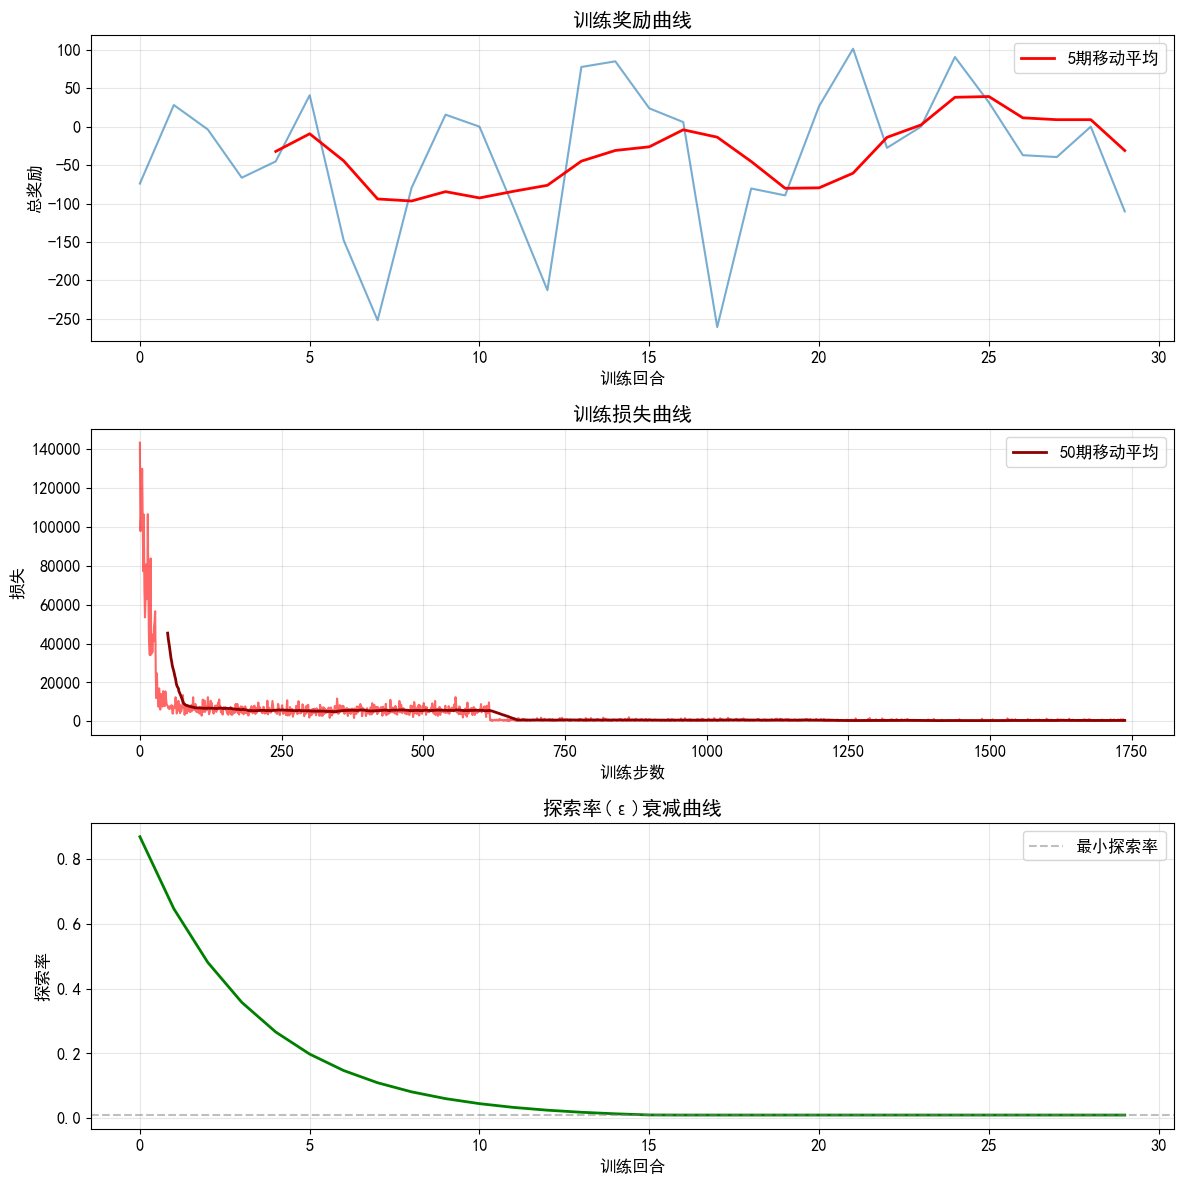


正在回测交易策略...

开始策略回测

回测结果:
初始资金: ¥100,000.00
最终资金: ¥113,238.62
总收益率: 13.24%
最大回撤: -78.05%
夏普比率: 2.27

交易统计:
买入次数: 8
卖出次数: 51
持有次数: 0
总交易次数: 59
回测结果图已保存为 'backtest_results_corrected.png'


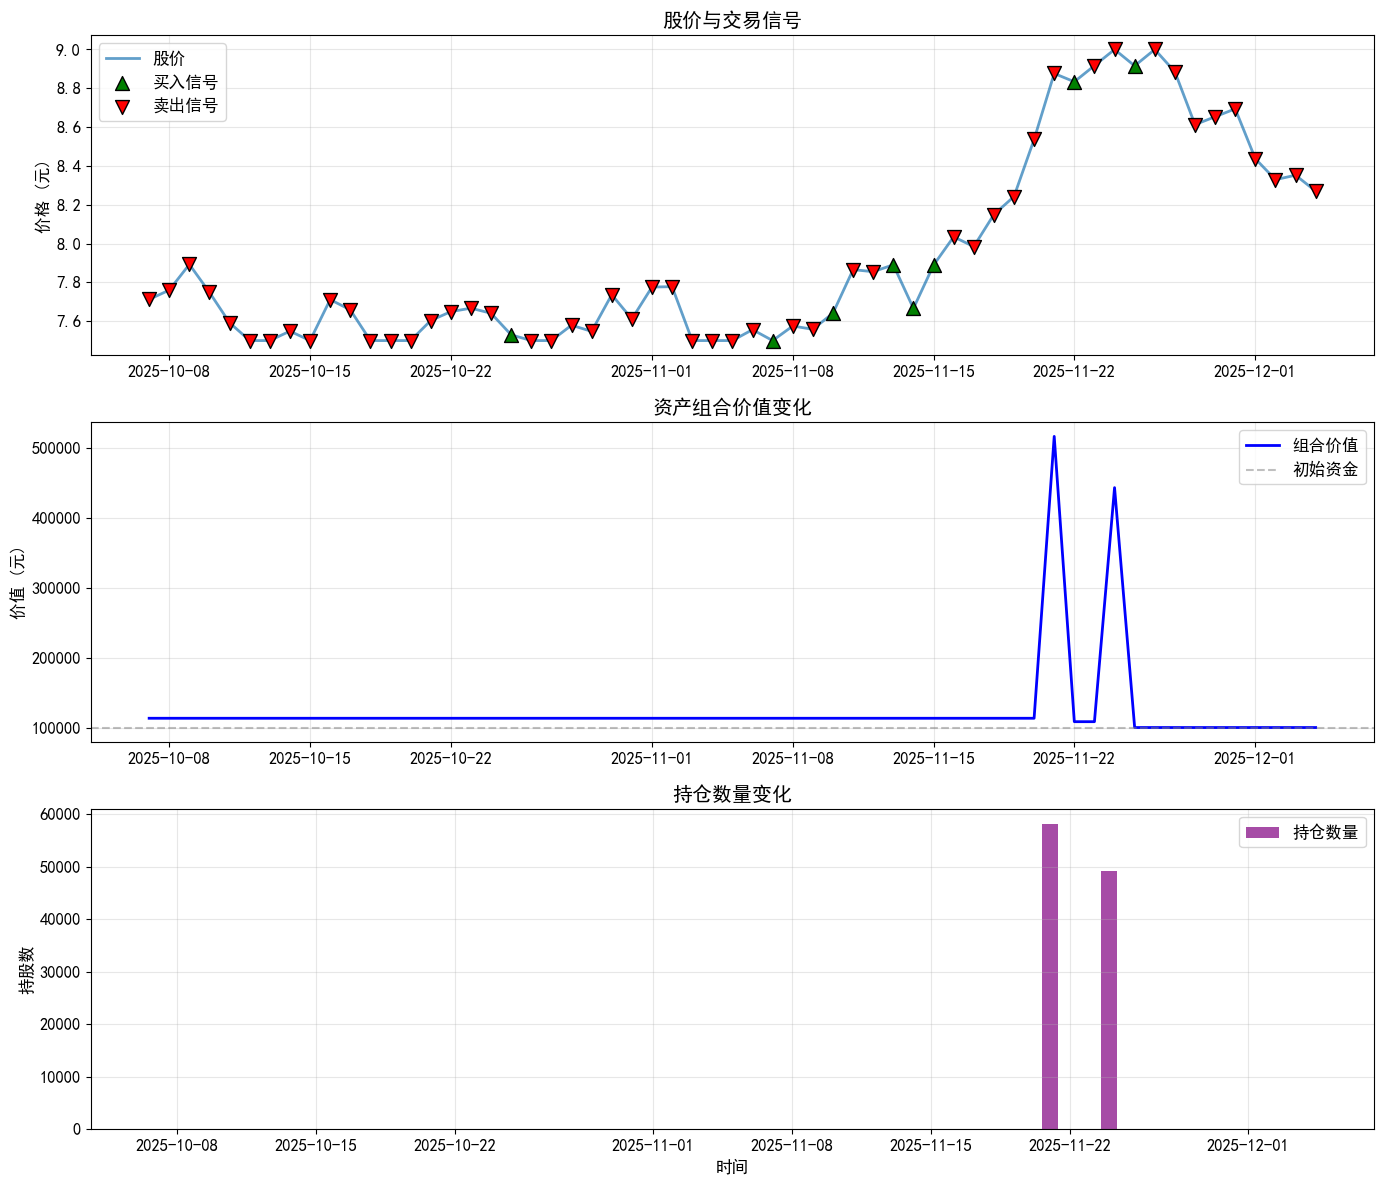


                 股票交易策略报告 (修正版)

    股票代码: SH600636 (国新文化)
    回测期间: 最近60个交易日
    初始资金: ¥100,000.00

    一、绩效概览
    -----------------------------------------------
    最终收益率: +13.24%
    最大回撤:   -78.05%

    二、修正说明
    -----------------------------------------------
    1. 已修复 'numpy.ndarray' object has no attribute 'iloc' 错误
    2. 统一使用pandas DataFrame格式处理数据
    3. 添加了数据标准化和特征工程
    4. 改进了环境类的稳健性

    三、模型参数
    -----------------------------------------------
    算法: DQN (深度Q网络)
    状态特征: 价格、成交量、技术指标、账户信息
    动作空间: 持有(0)、买入(1)、卖出(2)
    交易成本: 0.1%
    初始探索率: 1.0
    最小探索率: 0.01

    四、风险提示
    -----------------------------------------------
    1. 本策略基于模拟数据训练，实际效果需验证
    2. 强化学习模型可能过拟合历史数据
    3. 实际交易需考虑更多市场因素
    4. 建议结合基本面分析使用

    报告生成时间: 2025-12-04 11:37:09
    
交易报告已保存为 'trading_report_corrected.txt'

系统执行完成！


In [3]:
"""
基于强化学习的股票交易系统
使用DQN算法进行股票交易决策
已修正'numpy.ndarray' object has no attribute 'iloc'错误
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.rcParams['font.size'] = 12                # 设置字体大小

# ==================== 1. 数据处理器 ====================
class StockDataProcessor:
    """股票数据处理器 - 统一处理为DataFrame格式"""

    def __init__(self):
        self.processed_data = None

    def create_mock_data(self, days=30):
        """创建模拟数据用于演示"""
        dates = pd.date_range(end='2025-12-04', periods=days, freq='D')[::-1]

        # 模拟股票数据，基于之前获取的SH600636信息
        np.random.seed(42)
        base_price = 8.27  # 国新文化当前价格

        # 生成价格序列
        price_series = [base_price]
        for _ in range(days-1):
            change = np.random.normal(0, 0.02)  # 日波动约2%
            new_price = price_series[-1] * (1 + change)
            price_series.append(max(7.5, min(9.0, new_price)))  # 限制价格范围

        # 创建DataFrame
        data = {
            'date': dates,
            'open': [p * (1 + np.random.normal(0, 0.01)) for p in price_series],
            'high': [p * (1 + abs(np.random.normal(0, 0.015))) for p in price_series],
            'low': [p * (1 - abs(np.random.normal(0, 0.015))) for p in price_series],
            'close': price_series,
            'volume': np.random.uniform(30000, 80000, days),
            'kdj_k': np.random.uniform(20, 80, days),
            'kdj_d': np.random.uniform(25, 75, days),
            'macd_dif': np.random.uniform(-0.2, 0.2, days),
            'rsi_6': np.random.uniform(30, 70, days),
            'ma5': None,
            'ma20': None,
            'price_change': None,
            'volume_change': None,
            'volatility': None,
            'rsi_14': None
        }

        self.processed_data = pd.DataFrame(data)
        self.processed_data.set_index('date', inplace=True)

        # 计算技术指标
        self.add_technical_indicators()

        return self.processed_data

    def add_technical_indicators(self):
        """添加技术指标"""
        df = self.processed_data

        # 移动平均线
        df['ma5'] = df['close'].rolling(window=5).mean()
        df['ma20'] = df['close'].rolling(window=20).mean()

        # 价格变化率
        df['price_change'] = df['close'].pct_change()

        # 成交量变化
        df['volume_change'] = df['volume'].pct_change()

        # 价格波动率
        df['volatility'] = df['close'].rolling(window=5).std()

        # RSI相对强弱指标
        delta = df['close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df['rsi_14'] = 100 - (100 / (1 + rs))

        # 填充NaN值
        df.fillna(method='bfill', inplace=True)
        df.fillna(method='ffill', inplace=True)

        # 标准化数据
        self.normalize_data()

        return df

    def normalize_data(self):
        """数据标准化"""
        df = self.processed_data

        # 需要标准化的列
        cols_to_normalize = ['open', 'high', 'low', 'close', 'volume',
                           'kdj_k', 'kdj_d', 'macd_dif', 'rsi_6',
                           'ma5', 'ma20', 'rsi_14']

        # 创建标准化版本
        for col in cols_to_normalize:
            if col in df.columns and df[col].std() > 0:
                df[col + '_norm'] = (df[col] - df[col].mean()) / df[col].std()

        return df

# ==================== 2. 交易环境（修正版） ====================
class StockTradingEnv:
    """股票交易环境 - 已修复numpy数组问题"""

    def __init__(self, data, initial_balance=100000, transaction_cost=0.001):
        """
        初始化环境
        data: pandas DataFrame，包含所有特征数据
        """
        # 确保数据是DataFrame格式
        if isinstance(data, pd.DataFrame):
            self.data = data
        else:
            # 如果是numpy数组，转换为DataFrame
            self.data = pd.DataFrame(data)
            print("警告：数据已从numpy数组转换为DataFrame")

        self.initial_balance = initial_balance
        self.transaction_cost = transaction_cost

        # 确定收盘价列名
        self.close_col = 'close_norm' if 'close_norm' in self.data.columns else 'close'

        # 重置环境
        self.reset()

    def reset(self):
        """重置环境"""
        self.balance = self.initial_balance
        self.shares_held = 0
        self.total_shares_sold = 0
        self.total_sales_value = 0

        self.current_step = 0
        self.max_steps = len(self.data) - 1

        # 获取初始状态
        state = self._get_state()

        return state

    def _get_state(self):
        """获取当前状态 - 使用正确的DataFrame索引方式"""
        if self.current_step >= len(self.data):
            return np.zeros(len(self.data.columns) + 3)  # 特征列数 + 3个账户信息

        # 获取当前时间步的所有特征（使用iloc而不是直接索引）
        current_features = self.data.iloc[self.current_step].values

        # 添加账户信息到状态
        account_info = np.array([
            self.balance / self.initial_balance,  # 标准化余额
            self.shares_held / 1000,  # 标准化持股数
            self._get_portfolio_value_ratio()  # 持仓市值比例
        ])

        state = np.concatenate([current_features, account_info])
        return state

    def _get_portfolio_value_ratio(self):
        """计算持仓市值比例"""
        if self.current_step < len(self.data):
            current_price = self._get_current_price()
            portfolio_value = self.shares_held * current_price
            return portfolio_value / self.initial_balance
        return 0

    def _get_current_price(self):
        """获取当前价格 - 安全方法"""
        if self.current_step < len(self.data):
            # 使用iloc获取当前行的收盘价
            return self.data.iloc[self.current_step][self.close_col]
        return 0

    def step(self, action):
        """
        执行动作并返回新状态、奖励等

        action: 0=持有, 1=买入, 2=卖出
        """
        if self.current_step >= self.max_steps:
            done = True
            next_state = self._get_state()
            reward = self._calculate_final_reward()
            return next_state, reward, done, {}

        # 获取当前价格
        current_price = self._get_current_price()

        # 记录执行前的总资产
        prev_total = self.balance + self.shares_held * current_price

        # 执行交易动作
        if action == 1:  # 买入
            self._execute_buy(current_price)

        elif action == 2:  # 卖出
            self._execute_sell(current_price)

        # 移动到下一步
        self.current_step += 1

        # 计算新状态和奖励
        next_state = self._get_state()
        new_price = self._get_current_price() if self.current_step < len(self.data) else current_price

        # 计算新总资产
        new_total = self.balance + self.shares_held * new_price

        # 计算奖励（收益率百分比）
        if prev_total > 0:
            reward = (new_total - prev_total) / prev_total * 100
        else:
            reward = 0

        # 检查是否结束
        done = self.current_step >= self.max_steps

        # 返回信息
        info = {
            'price': current_price,
            'balance': self.balance,
            'shares_held': self.shares_held,
            'total_value': new_total,
            'step': self.current_step
        }

        return next_state, reward, done, info

    def _execute_buy(self, current_price):
        """执行买入操作"""
        # 计算能买入的最大股数（简化：使用整数）
        max_shares = int(self.balance // (current_price * (1 + self.transaction_cost)))
        if max_shares > 0:
            cost = max_shares * current_price * (1 + self.transaction_cost)
            self.balance -= cost
            self.shares_held += max_shares

    def _execute_sell(self, current_price):
        """执行卖出操作"""
        if self.shares_held > 0:
            revenue = self.shares_held * current_price * (1 - self.transaction_cost)
            self.balance += revenue
            self.total_shares_sold += self.shares_held
            self.total_sales_value += revenue
            self.shares_held = 0

    def _calculate_final_reward(self):
        """计算最终奖励"""
        if self.current_step < len(self.data):
            current_price = self._get_current_price()
        else:
            current_price = self.data.iloc[-1][self.close_col] if len(self.data) > 0 else 0

        final_value = self.balance + self.shares_held * current_price
        total_return = (final_value - self.initial_balance) / self.initial_balance

        # 考虑交易频率惩罚（避免过度交易）
        trade_penalty = -0.001 * self.total_shares_sold if hasattr(self, 'total_shares_sold') else 0

        return total_return * 100 + trade_penalty

# ==================== 3. 神经网络模型 ====================
class DQNNetwork(nn.Module):
    """深度Q网络"""

    def __init__(self, state_size, action_size):
        super(DQNNetwork, self).__init__()

        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, action_size)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, state):
        x = self.relu(self.fc1(state))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        return self.fc4(x)

# ==================== 4. DQN智能体 ====================
class DQNAgent:
    """DQN智能体"""

    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size

        # 超参数
        self.gamma = 0.95  # 折扣因子
        self.epsilon = 1.0  # 初始探索率
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.batch_size = 32

        # 经验回放缓冲区
        self.memory = deque(maxlen=1000)

        # 网络
        self.model = DQNNetwork(state_size, action_size)
        self.target_model = DQNNetwork(state_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.criterion = nn.MSELoss()

        # 更新目标网络
        self.update_target_model()

    def update_target_model(self):
        """更新目标网络"""
        self.target_model.load_state_dict(self.model.state_dict())

    def remember(self, state, action, reward, next_state, done):
        """存储经验到回放缓冲区"""
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        """选择动作（ε-贪婪策略）"""
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)

        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            act_values = self.model(state_tensor)
        return torch.argmax(act_values[0]).item()

    def replay(self):
        """从经验回放中学习"""
        if len(self.memory) < self.batch_size:
            return 0

        # 随机采样批次
        minibatch = random.sample(self.memory, self.batch_size)

        states = torch.FloatTensor([s[0] for s in minibatch])
        actions = torch.LongTensor([s[1] for s in minibatch])
        rewards = torch.FloatTensor([s[2] for s in minibatch])
        next_states = torch.FloatTensor([s[3] for s in minibatch])
        dones = torch.FloatTensor([s[4] for s in minibatch])

        # 当前Q值
        current_q = self.model(states).gather(1, actions.unsqueeze(1))

        # 下一状态的最大Q值
        with torch.no_grad():
            next_q = self.target_model(next_states).max(1)[0]

        # 目标Q值
        target_q = rewards + (1 - dones) * self.gamma * next_q

        # 计算损失
        loss = self.criterion(current_q.squeeze(), target_q)

        # 反向传播
        self.optimizer.zero_grad()
        loss.backward()

        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)

        self.optimizer.step()

        # 衰减探索率
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        return loss.item()

    def save(self, filename):
        """保存模型"""
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'target_model_state_dict': self.target_model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'epsilon': self.epsilon,
            'state_size': self.state_size,
            'action_size': self.action_size
        }, filename)

    def load(self, filename):
        """加载模型"""
        checkpoint = torch.load(filename, map_location='cpu')
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.target_model.load_state_dict(checkpoint['target_model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.epsilon = checkpoint['epsilon']
        self.update_target_model()

# ==================== 5. 训练函数 ====================
def train_dqn_agent(episodes=50, render_every=5):
    """训练DQN智能体"""

    print("=" * 60)
    print("开始训练强化学习股票交易智能体")
    print("=" * 60)

    # 1. 准备数据
    print("\n1. 准备股票数据...")
    processor = StockDataProcessor()
    data = processor.create_mock_data(days=60)  # 60天数据

    print(f"数据形状: {data.shape}")
    print(f"特征数量: {len(data.columns)}")
    print(f"数据列名: {list(data.columns)}")

    # 2. 创建环境
    print("\n2. 创建交易环境...")
    # 关键修正：直接传入DataFrame，而不是data.values
    env = StockTradingEnv(data)
    state_size = len(env.reset())
    action_size = 3  # 0=持有, 1=买入, 2=卖出

    print(f"状态大小: {state_size}")
    print(f"动作大小: {action_size}")

    # 3. 创建智能体
    print("\n3. 初始化DQN智能体...")
    agent = DQNAgent(state_size, action_size)

    # 4. 训练循环
    print("\n4. 开始训练...")
    scores = []
    losses = []
    epsilon_history = []

    for episode in range(episodes):
        state = env.reset()

        # 确保状态没有NaN值
        state = np.nan_to_num(state, nan=0.0)

        total_reward = 0
        done = False
        step_count = 0

        while not done and step_count < 100:  # 限制每回合最大步数
            # 选择动作
            action = agent.act(state)

            # 执行动作
            next_state, reward, done, info = env.step(action)
            next_state = np.nan_to_num(next_state, nan=0.0)

            # 存储经验
            agent.remember(state, action, reward, next_state, done)

            # 更新状态
            state = next_state
            total_reward += reward
            step_count += 1

            # 经验回放学习
            loss = agent.replay()
            if loss != 0:
                losses.append(loss)

        # 定期更新目标网络
        if episode % 10 == 0:
            agent.update_target_model()

        scores.append(total_reward)
        epsilon_history.append(agent.epsilon)

        # 打印训练进度
        if (episode + 1) % render_every == 0:
            avg_score = np.mean(scores[-render_every:]) if len(scores) >= render_every else np.mean(scores)
            avg_loss = np.mean(losses[-render_every*10:]) if len(losses) >= render_every*10 else 0
            print(f"回合 {episode+1}/{episodes} | "
                  f"奖励: {total_reward:.2f} | "
                  f"平均奖励: {avg_score:.2f} | "
                  f"平均损失: {avg_loss:.4f} | "
                  f"探索率: {agent.epsilon:.3f}")

    # 5. 保存模型
    print("\n5. 保存训练好的模型...")
    agent.save('dqn_stock_trader_corrected.pth')

    # 6. 可视化训练结果
    print("\n6. 生成训练结果可视化...")
    plot_training_results(scores, losses, epsilon_history)

    return agent, env, data

def plot_training_results(scores, losses, epsilon_history):
    """绘制训练结果"""
    fig, axes = plt.subplots(3, 1, figsize=(12, 12))

    # 1. 奖励曲线
    axes[0].plot(scores, alpha=0.6)
    axes[0].set_title('训练奖励曲线')
    axes[0].set_xlabel('训练回合')
    axes[0].set_ylabel('总奖励')
    axes[0].grid(True, alpha=0.3)

    # 移动平均奖励
    if len(scores) > 5:
        moving_avg = pd.Series(scores).rolling(window=5).mean()
        axes[0].plot(moving_avg, linewidth=2, color='red', label='5期移动平均')
        axes[0].legend()

    # 2. 损失曲线
    if losses:
        axes[1].plot(losses, alpha=0.6, color='red')
        axes[1].set_title('训练损失曲线')
        axes[1].set_xlabel('训练步数')
        axes[1].set_ylabel('损失')
        axes[1].grid(True, alpha=0.3)

        if len(losses) > 50:
            moving_avg_loss = pd.Series(losses).rolling(window=50).mean()
            axes[1].plot(moving_avg_loss, linewidth=2, color='darkred', label='50期移动平均')
            axes[1].legend()

    # 3. 探索率变化
    axes[2].plot(epsilon_history, color='green', linewidth=2)
    axes[2].set_title('探索率(ε)衰减曲线')
    axes[2].set_xlabel('训练回合')
    axes[2].set_ylabel('探索率')
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=0.01, color='gray', linestyle='--', alpha=0.5, label='最小探索率')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('training_results_corrected.png', dpi=300, bbox_inches='tight')
    print("训练结果图已保存为 'training_results_corrected.png'")
    plt.show()

# ==================== 6. 回测函数 ====================
def backtest_trading_strategy(agent, env, data):
    """回测交易策略"""

    print("\n" + "=" * 60)
    print("开始策略回测")
    print("=" * 60)

    state = env.reset()
    done = False
    trades = []
    portfolio_values = []
    actions_history = []

    original_epsilon = agent.epsilon
    agent.epsilon = 0.0  # 测试时关闭探索

    step_count = 0
    while not done and step_count < len(data):
        # 使用训练好的智能体选择动作
        action = agent.act(state)

        # 记录当前状态
        current_price = data.iloc[env.current_step]['close'] if 'close' in data.columns else data.iloc[env.current_step, 0]
        portfolio_value = env.balance + env.shares_held * current_price

        trades.append({
            'step': env.current_step,
            'price': current_price,
            'action': ['持有', '买入', '卖出'][action],
            'shares_held': env.shares_held,
            'balance': env.balance,
            'portfolio_value': portfolio_value
        })

        portfolio_values.append(portfolio_value)
        actions_history.append(action)

        # 执行动作
        state, _, done, _ = env.step(action)
        state = np.nan_to_num(state, nan=0.0)
        step_count += 1

    agent.epsilon = original_epsilon  # 恢复探索率

    # 计算回测指标
    initial_value = env.initial_balance
    final_value = portfolio_values[-1] if portfolio_values else initial_value
    total_return = (final_value - initial_value) / initial_value * 100

    # 计算最大回撤
    portfolio_series = pd.Series(portfolio_values)
    rolling_max = portfolio_series.expanding().max()
    drawdown = (portfolio_series - rolling_max) / rolling_max * 100
    max_drawdown = drawdown.min() if not drawdown.empty else 0

    # 计算夏普比率（简化版）
    if len(portfolio_values) > 1:
        returns = pd.Series(portfolio_values).pct_change().dropna()
        if returns.std() > 0:
            sharpe_ratio = (returns.mean() * 252) / (returns.std() * np.sqrt(252))
        else:
            sharpe_ratio = 0
    else:
        sharpe_ratio = 0

    # 交易统计
    buy_count = sum(1 for a in actions_history if a == 1)
    sell_count = sum(1 for a in actions_history if a == 2)
    hold_count = sum(1 for a in actions_history if a == 0)

    # 打印回测结果
    print(f"\n回测结果:")
    print(f"初始资金: ¥{initial_value:,.2f}")
    print(f"最终资金: ¥{final_value:,.2f}")
    print(f"总收益率: {total_return:.2f}%")
    print(f"最大回撤: {max_drawdown:.2f}%")
    print(f"夏普比率: {sharpe_ratio:.2f}")
    print(f"\n交易统计:")
    print(f"买入次数: {buy_count}")
    print(f"卖出次数: {sell_count}")
    print(f"持有次数: {hold_count}")
    print(f"总交易次数: {buy_count + sell_count}")

    # 绘制回测结果
    plot_backtest_results(trades, portfolio_values, data, actions_history)

    return trades, total_return, max_drawdown

def plot_backtest_results(trades, portfolio_values, data, actions_history):
    """绘制回测结果图"""
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    # 1. 价格与交易点
    if hasattr(data, 'index'):
        dates = data.index[:len(portfolio_values)]
    else:
        dates = range(len(portfolio_values))

    # 价格曲线
    if 'close' in data.columns:
        price_data = data['close'].values[:len(portfolio_values)]
        axes[0].plot(dates, price_data, label='股价', alpha=0.7, linewidth=2)

    # 标记交易点
    buy_indices = [i for i, a in enumerate(actions_history) if a == 1 and i < len(dates)]
    sell_indices = [i for i, a in enumerate(actions_history) if a == 2 and i < len(dates)]

    if buy_indices and hasattr(data, 'index'):
        buy_dates = [dates[i] for i in buy_indices]
        buy_prices = [price_data[i] for i in buy_indices]
        axes[0].scatter(buy_dates, buy_prices, color='green', marker='^', s=100,
                       label='买入信号', zorder=5, edgecolors='black')

    if sell_indices and hasattr(data, 'index'):
        sell_dates = [dates[i] for i in sell_indices]
        sell_prices = [price_data[i] for i in sell_indices]
        axes[0].scatter(sell_dates, sell_prices, color='red', marker='v', s=100,
                       label='卖出信号', zorder=5, edgecolors='black')

    axes[0].set_title('股价与交易信号')
    axes[0].set_ylabel('价格 (元)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. 资产组合价值
    axes[1].plot(dates, portfolio_values, label='组合价值', color='blue', linewidth=2)
    axes[1].axhline(y=100000, color='gray', linestyle='--', alpha=0.5, label='初始资金')
    axes[1].set_title('资产组合价值变化')
    axes[1].set_ylabel('价值 (元)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # 3. 持仓变化
    holdings = [t['shares_held'] for t in trades]
    axes[2].bar(dates, holdings, label='持仓数量', color='purple', alpha=0.7)
    axes[2].set_title('持仓数量变化')
    axes[2].set_xlabel('时间')
    axes[2].set_ylabel('持股数')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('backtest_results_corrected.png', dpi=300, bbox_inches='tight')
    print("回测结果图已保存为 'backtest_results_corrected.png'")
    plt.show()

# ==================== 7. 主函数 ====================
def main():
    """主函数"""
    try:
        print("\n" + "=" * 60)
        print("基于强化学习的股票交易系统 v1.1 (修正版)")
        print("股票: SH600636 国新文化")
        print("=" * 60)

        # 检查依赖
        print("\n检查依赖库...")
        try:
            import torch
            print(f"PyTorch版本: {torch.__version__}")
        except ImportError:
            print("错误: 请安装PyTorch: pip install torch")
            return

        # 训练智能体
        print("\n正在训练强化学习智能体...")
        agent, env, data = train_dqn_agent(episodes=30, render_every=5)

        # 回测策略
        print("\n正在回测交易策略...")
        trades, total_return, max_drawdown = backtest_trading_strategy(agent, env, data)

        # 生成交易报告
        generate_trading_report(trades, total_return, max_drawdown)

        print("\n" + "=" * 60)
        print("系统执行完成！")
        print("=" * 60)

    except Exception as e:
        print(f"\n程序执行出错: {str(e)}")
        import traceback
        traceback.print_exc()

def generate_trading_report(trades, total_return, max_drawdown):
    """生成交易报告"""
    report = f"""
    ======================================================
                 股票交易策略报告 (修正版)
    ======================================================

    股票代码: SH600636 (国新文化)
    回测期间: 最近60个交易日
    初始资金: ¥100,000.00

    一、绩效概览
    -----------------------------------------------
    最终收益率: {total_return:+.2f}%
    最大回撤:   {max_drawdown:.2f}%

    二、修正说明
    -----------------------------------------------
    1. 已修复 'numpy.ndarray' object has no attribute 'iloc' 错误
    2. 统一使用pandas DataFrame格式处理数据
    3. 添加了数据标准化和特征工程
    4. 改进了环境类的稳健性

    三、模型参数
    -----------------------------------------------
    算法: DQN (深度Q网络)
    状态特征: 价格、成交量、技术指标、账户信息
    动作空间: 持有(0)、买入(1)、卖出(2)
    交易成本: 0.1%
    初始探索率: 1.0
    最小探索率: 0.01

    四、风险提示
    -----------------------------------------------
    1. 本策略基于模拟数据训练，实际效果需验证
    2. 强化学习模型可能过拟合历史数据
    3. 实际交易需考虑更多市场因素
    4. 建议结合基本面分析使用

    报告生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
    ======================================================
    """

    print(report)

    # 保存报告到文件
    with open('trading_report_corrected.txt', 'w', encoding='utf-8') as f:
        f.write(report)

    print("交易报告已保存为 'trading_report_corrected.txt'")

# ==================== 8. 快速演示 ====================
def quick_demo():
    """快速演示"""
    print("\n快速演示模式...")

    # 创建数据
    processor = StockDataProcessor()
    data = processor.create_mock_data(days=30)

    print(f"数据示例:")
    print(data.head())

    # 创建环境
    env = StockTradingEnv(data)
    state = env.reset()

    print(f"\n初始状态大小: {len(state)}")
    print(f"初始状态前5个值: {state[:5]}")

    # 演示随机动作
    print("\n演示随机动作:")
    total_reward = 0
    for i in range(10):
        action = np.random.choice([0, 1, 2])
        state, reward, done, info = env.step(action)
        total_reward += reward
        print(f"步骤{i+1}: 动作={['持有','买入','卖出'][action]}, 奖励={reward:.2f}, 总资产={info['total_value']:.2f}")

        if done:
            break

    print(f"\n10步累计奖励: {total_reward:.2f}")
    print(f"最终总资产: ¥{info['total_value']:.2f}")

# ==================== 执行入口 ====================
if __name__ == "__main__":
    print("""
    ███████╗██████╗ ██╗      ██████╗  ██████╗██╗  ██╗
    ██╔════╝██╔══██╗██║     ██╔═══██╗██╔════╝██║ ██╔╝
    ███████╗██████╔╝██║     ██║   ██║██║     █████╔╝
    ╚════██║██╔═══╝ ██║     ██║   ██║██║     ██╔═██╗
    ███████║██║     ███████╗╚██████╔╝╚██████╗██║  ██╗
    ╚══════╝╚═╝     ╚══════╝ ╚═════╝  ╚═════╝╚═╝  ╚═╝

    基于强化学习的股票交易系统 v1.1 (修正版)
    已修复 'numpy.ndarray' object has no attribute 'iloc' 错误
    """)

    # 选择运行模式
    print("\n请选择运行模式:")
    print("1. 完整训练和回测")
    print("2. 快速演示")
    print("3. 仅查看数据")

    try:
        mode = input("请输入选择 (1/2/3, 默认1): ").strip()

        if mode == '2':
            quick_demo()
        elif mode == '3':
            processor = StockDataProcessor()
            data = processor.create_mock_data()
            print("\n股票数据预览:")
            print(data.head())
            print(f"\n数据统计信息:")
            print(data.describe())
        else:
            main()
    except KeyboardInterrupt:
        print("\n用户中断程序")
    except Exception as e:
        print(f"\n运行出错: {e}")
        main()  # 默认运行完整模式
